# Klasifikasi Sawah dan Non-Sawah Menggunakan Citra Sentinel-2A dengan Random Forest

Notebook ini melakukan klasifikasi penutup lahan dua kelas, yaitu **sawah** (kelas 1) dan **non-sawah** (kelas 0), menggunakan citra **Sentinel-2A Level-2A** dan algoritma **Random Forest** (*scikit-learn*). Data sampel berupa poligon hasil digitasi di QGIS, masing-masing 50 poligon untuk setiap kelas.

Tahapan yang dilakukan adalah sebagai berikut:

1. Persiapan lingkungan, pustaka, dan data.
2. Penetapan parameter.
3. Pembacaan poligon sampel (*shapefile*) dan penentuan area kajian, disertai peta batas administratif Kecamatan Waru dan peta interaktif lokasi sampel.
4. Penyediaan citra Sentinel-2A (menggunakan citra yang telah tersedia atau mengunduh dari Copernicus).
5. Pembacaan citra dan pembentukan fitur (band dan indeks spektral).
6. Rasterisasi poligon sampel.
7. Pembagian data latih dan data uji per poligon.
8. Pelatihan model dan evaluasi.
9. Klasifikasi seluruh citra dan penghitungan luas.
10. Penyimpanan keluaran (GeoTIFF, peta, dan ringkasan evaluasi).

## 1. Persiapan Lingkungan dan Data

Sel berikut memasang pustaka yang belum tersedia (`rasterio` dan `geopandas`) serta memuat seluruh pustaka yang digunakan.

In [10]:
import subprocess, sys

try:
    import rasterio, geopandas, folium
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio", "geopandas", "folium"])

**Penjelasan kode:** Kode ini memeriksa ketersediaan `rasterio`, `geopandas`, dan `folium`. Apabila belum terpasang (misalnya pada Google Colab), ketiga pustaka tersebut dipasang secara otomatis menggunakan `pip`.

In [11]:
import datetime as dt
import io
import math
import os
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
from folium.plugins import Fullscreen
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio import features
from rasterio.warp import transform_bounds, transform_geom
from shapely.geometry import mapping, shape
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)

**Penjelasan kode:** Kode ini mengimpor pustaka untuk pengolahan data vektor (`geopandas`, `shapely`), data raster (`rasterio`), komputasi numerik (`numpy`, `pandas`), visualisasi statis (`matplotlib`) dan interaktif (`folium`), permintaan ke layanan Copernicus dan penyedia batas administratif (`requests`), serta model dan metrik evaluasi (`scikit-learn`).

In [12]:
import zipfile

IN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path("/content") if IN_COLAB else Path.cwd()
ZIP_SAWAH = BASE_DIR / "sawah.zip"
ZIP_NONSAWAH = BASE_DIR / "non-sawah.zip"

# Di Google Colab: unggah sawah.zip dan non-sawah.zip
# (serta sentinel2a_aoi.tif bila citra sudah diunduh sendiri)
if IN_COLAB and not (ZIP_SAWAH.exists() and ZIP_NONSAWAH.exists()):
    from google.colab import files
    print("Unggah sawah.zip, non-sawah.zip, dan (opsional) sentinel2a_aoi.tif")
    files.upload()

for berkas in (ZIP_SAWAH, ZIP_NONSAWAH):
    if not berkas.exists():
        raise FileNotFoundError(f"{berkas.name} tidak ditemukan di {BASE_DIR}")

for berkas, folder in ((ZIP_SAWAH, "datasawah50"), (ZIP_NONSAWAH, "nonsawah")):
    with zipfile.ZipFile(berkas) as zf:
        zf.extractall(BASE_DIR / folder)

print("Folder kerja:", BASE_DIR)
print("Sawah    :", sorted(p.name for p in (BASE_DIR / "datasawah50").iterdir()))
print("Non-sawah:", sorted(p.name for p in (BASE_DIR / "nonsawah").iterdir()))

Folder kerja: /content
Sawah    : ['input.dbf', 'input.prj', 'input.shp', 'input.shx']
Non-sawah: ['input.dbf', 'input.prj', 'input.shp', 'input.shx']


**Penjelasan kode:** Kode ini menentukan folder kerja (`/content` pada Google Colab atau folder aktif pada komputer lokal), meminta unggahan berkas ZIP apabila belum tersedia, kemudian mengekstraknya ke folder `datasawah50/` dan `nonsawah/`. Setiap ZIP berisi satu set *shapefile* (`.shp`, `.shx`, `.dbf`, `.prj`).

## 2. Parameter

Seluruh pengaturan dikumpulkan pada satu sel agar mudah diubah. Apabila berkas `sentinel2a_aoi.tif` belum tersedia di folder kerja, citra akan diunduh otomatis dari Copernicus untuk area kajian yang dihitung dari *shapefile* sampel. Apabila berkas tersebut sudah ada (misalnya diunggah manual), proses unduh dilewati kecuali `UNDUH_ULANG = True`.

In [13]:
# --- Pencarian citra (hanya dipakai bila citra diunduh) ---
UNDUH_ULANG = False            # True: unduh ulang citra dari Copernicus
START_DATE = "2026-08-01"
END_DATE = "2026-10-04"
PLATFORM_PREFIX = "S2A"        # hanya Sentinel-2A; None untuk semua satelit Sentinel-2
MAX_CLOUD = 30                 # persen awan maksimum (level tile)
MAX_TRIES = 5                  # jumlah scene terbaik yang dicoba
MIN_VALID = 0.90               # minimal fraksi piksel bebas awan
MASK_CLOUD = True              # masking awan memakai band SCL
BUFFER_M = 1500                # margin area unduhan di sekeliling sampel (meter)

# --- Sampel dan model ---
N_SAMPLE = 50                  # jumlah poligon sampel per kelas
FILE_SAWAH = sorted((BASE_DIR / "datasawah50").glob("*.shp"))[0]     # kelas 1
FILE_NONSAWAH = sorted((BASE_DIR / "nonsawah").glob("*.shp"))[0]     # kelas 0
TRAIN_FRAC = 0.7               # proporsi poligon untuk data latih
N_TREES = 200
SEED = 42

# --- Berkas ---
TIF_IN = BASE_DIR / "sentinel2a_aoi.tif"
INFO_TXT = BASE_DIR / "sentinel2a_aoi_info.txt"
OUT_TIF = BASE_DIR / "klasifikasi_sawah_s2a.tif"
OUT_PNG = BASE_DIR / "peta_klasifikasi.png"
OUT_TXT = BASE_DIR / "hasil_evaluasi.txt"

BAND_NAMES = ["B02", "B03", "B04", "B08", "B11", "B12"]

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

LOG = []

def log(*args):
    s = " ".join(str(a) for a in args)
    print(s)
    LOG.append(s)

**Penjelasan kode:** Kode ini menetapkan parameter pencarian citra, jumlah sampel (50 poligon per kelas), proporsi data latih (70%), jumlah pohon Random Forest (200), *random seed* (42), serta lokasi berkas masukan dan keluaran. Fungsi `log()` mencetak teks sekaligus menyimpannya ke daftar `LOG` yang kemudian ditulis menjadi `hasil_evaluasi.txt`.

## 3. Pembacaan Poligon Sampel dan Penentuan Area Kajian

Poligon sampel dibaca dari *shapefile*, diproyeksikan ke WGS-84 (EPSG:4326), dan dipilih secara acak sebanyak `N_SAMPLE` poligon per kelas. Kotak pembatas (*bounding box*) seluruh sampel ditambah margin `BUFFER_M` digunakan sebagai area kajian.

In [14]:
def read_samples_gdf(path, n):
    gdf = gpd.read_file(path)
    total = len(gdf)
    gdf = gdf[gdf.geometry.notna()].copy()

    if gdf.crs is None:
        log(f"PERINGATAN: {Path(path).name} tidak memiliki CRS. Diasumsikan EPSG:4326.")
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    if len(gdf) > n:
        idx = np.random.default_rng(SEED).choice(len(gdf), n, replace=False)
        gdf = gdf.iloc[sorted(idx)].copy()
    elif len(gdf) < n:
        log(f"PERINGATAN: {Path(path).name} hanya berisi {total} poligon (< {n}).")

    log(f"{Path(path).name}: {total} poligon di file -> dipakai {len(gdf)}")
    return gdf.reset_index(drop=True)


def iter_xy(c):
    if isinstance(c[0], (int, float)):
        yield c[0], c[1]
    else:
        for s in c:
            yield from iter_xy(s)


gdf_sawah = read_samples_gdf(FILE_SAWAH, N_SAMPLE)
gdf_non = read_samples_gdf(FILE_NONSAWAH, N_SAMPLE)
geoms_sawah = [mapping(g) for g in gdf_sawah.geometry]
geoms_non = [mapping(g) for g in gdf_non.geometry]

xy = [p for g in geoms_sawah + geoms_non for p in iter_xy(g["coordinates"])]
pad = BUFFER_M / 111000.0
BBOX = (min(x for x, _ in xy) - pad, min(y for _, y in xy) - pad,
        max(x for x, _ in xy) + pad, max(y for _, y in xy) + pad)
log("BBox area (lon/lat):", tuple(round(v, 5) for v in BBOX))

input.shp: 50 poligon di file -> dipakai 50
input.shp: 50 poligon di file -> dipakai 50
BBox area (lon/lat): (113.52781, -6.95743, 113.56482, -6.91945)


**Penjelasan kode:** Fungsi `read_samples_gdf` membaca *shapefile*, membuang fitur tanpa geometri, mengubah sistem koordinat ke EPSG:4326, lalu memilih secara acak paling banyak 50 poligon (hasil pemilihan tetap karena `SEED` tetap). Hasilnya disimpan sebagai `gdf_sawah` dan `gdf_non` agar dapat dipakai kembali pada pembuatan peta, sedangkan `geoms_sawah` dan `geoms_non` adalah versi geometri untuk rasterisasi. Fungsi `iter_xy` meratakan koordinat poligon agar batas terluar seluruh sampel dapat dihitung. Margin `BUFFER_M` dikonversi ke derajat dengan pendekatan 1 derajat ≈ 111.000 m.

### 3.1 Batas Administratif Kecamatan Waru

Batas administratif Kecamatan Waru (Kabupaten Pamekasan, Jawa Timur) diambil dari **OpenStreetMap** (Nominatim). Apabila gagal, digunakan **geoBoundaries** (ADM3). Hasilnya disimpan ke `batas_kecamatan_waru.geojson` sehingga pada eksekusi berikutnya tidak perlu mengunduh ulang. Berkas tersebut juga boleh diganti dengan batas resmi milik Anda (GeoJSON atau *shapefile*) asalkan namanya sama. Sel ini sekaligus memeriksa berapa poligon sampel yang benar-benar berada di dalam batas kecamatan.

In [15]:
KEC_NAMA, KAB_NAMA, PROV_NAMA = "Waru", "Pamekasan", "Jawa Timur"
BATAS_FILE = BASE_DIR / "batas_kecamatan_waru.geojson"   # hapus berkas ini untuk mengunduh ulang
OUT_BATAS_PNG = BASE_DIR / "peta_batas_waru.png"

# Satu titik di dalam tiap poligon sampel, dipakai untuk memilih/memeriksa batas
titik_sampel = pd.concat([gdf_sawah.geometry, gdf_non.geometry]).representative_point()


def pilih_dari_sampel(cand):
    """Dari beberapa kandidat 'Waru', pilih yang paling banyak memuat titik sampel."""
    skor = [int(titik_sampel.within(g).sum()) for g in cand.geometry]
    return cand.iloc[[int(np.argmax(skor))]]


def ambil_batas_nominatim():
    r = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={"q": f"{KEC_NAMA}, {KAB_NAMA}, {PROV_NAMA}, Indonesia", "format": "jsonv2",
                "polygon_geojson": 1, "limit": 10},
        headers={"User-Agent": "klasifikasi-sawah-sentinel2a/1.0 (penelitian akademik)"},
        timeout=60)
    r.raise_for_status()
    geoms = [shape(h["geojson"]) for h in r.json()
             if h.get("category") == "boundary"
             and h.get("geojson", {}).get("type") in ("Polygon", "MultiPolygon")
             and KAB_NAMA.lower() in h.get("display_name", "").lower()]
    if not geoms:
        raise RuntimeError("poligon batas tidak ditemukan")
    return pilih_dari_sampel(gpd.GeoDataFrame({"nama": KEC_NAMA}, geometry=geoms, crs="EPSG:4326"))


def ambil_batas_geoboundaries():
    meta = requests.get("https://www.geoboundaries.org/api/current/gbOpen/IDN/ADM3/", timeout=60)
    meta.raise_for_status()
    r = requests.get(meta.json()["simplifiedGeometryGeoJSON"], timeout=300)
    r.raise_for_status()
    gdf = gpd.read_file(io.BytesIO(r.content)).to_crs(epsg=4326)
    cand = gdf[gdf["shapeName"].str.strip().str.lower() == KEC_NAMA.lower()]
    if cand.empty:
        raise RuntimeError(f"kecamatan {KEC_NAMA} tidak ditemukan")
    return pilih_dari_sampel(cand.assign(nama=KEC_NAMA)[["nama", "geometry"]])


batas_waru, sumber_batas = None, None
if BATAS_FILE.exists():
    batas_waru = gpd.read_file(BATAS_FILE).to_crs(epsg=4326)
    sumber_batas = f"berkas lokal ({BATAS_FILE.name})"
else:
    for nama_sumber, fungsi in (("OpenStreetMap (Nominatim)", ambil_batas_nominatim),
                                ("geoBoundaries ADM3", ambil_batas_geoboundaries)):
        try:
            batas_waru, sumber_batas = fungsi(), nama_sumber
            batas_waru[["nama", "geometry"]].to_file(BATAS_FILE, driver="GeoJSON")
            break
        except Exception as e:
            log(f"PERINGATAN: batas dari {nama_sumber} gagal ({e}).")

if batas_waru is None:
    log("PERINGATAN: batas kecamatan tidak tersedia. Unggah batas_kecamatan_waru.geojson "
        "ke folder kerja lalu jalankan ulang sel ini.")
else:
    luas_km2 = batas_waru.to_crs(batas_waru.estimate_utm_crs()).area.sum() / 1e6
    batas_union = batas_waru.geometry.union_all()
    n_dalam = int(titik_sampel.within(batas_union).sum())
    log(f"Batas Kecamatan {KEC_NAMA} dari {sumber_batas} | luas ≈ {luas_km2:.1f} km²")
    log(f"Poligon sampel di dalam batas kecamatan: {n_dalam} dari {len(titik_sampel)}")
    if n_dalam < len(titik_sampel):
        log("CATATAN: sebagian sampel berada di luar batas. Periksa nama kecamatan/kabupaten "
            "(KEC_NAMA, KAB_NAMA) atau posisi digitasi.")

    # Peta statis
    fig, ax = plt.subplots(figsize=(7, 7))
    batas_waru.plot(ax=ax, facecolor="#f4efdf", edgecolor="black", linewidth=1.8)
    gdf_sawah.plot(ax=ax, facecolor="#1a9641", edgecolor="#0b5d27", linewidth=0.5)
    gdf_non.plot(ax=ax, facecolor="#d7191c", edgecolor="#7f0d0f", linewidth=0.5)
    ax.legend(handles=[
        Patch(facecolor="#f4efdf", edgecolor="black", label=f"Batas Kecamatan {KEC_NAMA}"),
        Patch(facecolor="#1a9641", label=f"Sampel sawah ({len(gdf_sawah)})"),
        Patch(facecolor="#d7191c", label=f"Sampel non-sawah ({len(gdf_non)})")],
        loc="lower left")
    ax.set_title(f"Batas Administratif Kecamatan {KEC_NAMA}, Kabupaten {KAB_NAMA}")
    ax.set_xlabel("Bujur (°BT)")
    ax.set_ylabel("Lintang (°LU/LS)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_BATAS_PNG, dpi=150)
    plt.show()

PERINGATAN: batas dari OpenStreetMap (Nominatim) gagal (poligon batas tidak ditemukan).
PERINGATAN: batas dari geoBoundaries ADM3 gagal (404 Client Error: Not Found for url: https://www.geoboundaries.org/api/current/gbOpen/IDN/ADM3/).
PERINGATAN: batas kecamatan tidak tersedia. Unggah batas_kecamatan_waru.geojson ke folder kerja lalu jalankan ulang sel ini.


**Penjelasan kode:** Kode ini mengambil poligon batas Kecamatan Waru dari OpenStreetMap (cadangan: geoBoundaries), memilih poligon yang paling banyak memuat sampel apabila ada beberapa kecamatan bernama Waru, lalu menyimpannya sebagai `batas_kecamatan_waru.geojson`. Luas kecamatan dihitung pada proyeksi UTM yang sesuai, jumlah poligon sampel yang berada di dalam batas dicatat ke `LOG`, dan peta statis batas beserta sampel disimpan sebagai `peta_batas_waru.png`.

### 3.2 Peta Interaktif Lokasi Sampel

Peta interaktif berlatar citra satelit Esri menampilkan poligon sampel sawah dan non-sawah beserta garis batas Kecamatan Waru, sehingga jelas bahwa seluruh analisis ini memakai wilayah Kecamatan Waru. Peta juga disimpan sebagai berkas HTML.

In [26]:
# 2. Membuat Peta Interaktif dengan Esri Satelit sebagai Basemap Utama
minx, miny, maxx, maxy = pd.concat([sawah.geometry, non.geometry]).total_bounds
m = folium.Map(
    location=[(miny + maxy) / 2, (minx + maxx) / 2],
    zoom_start=15,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    control_scale=True
)

# Memasukkan poligon poligon sampel ke peta
for gdf, nama, warna in ((sawah, "Sawah", WARNA["sawah"]), (non, "Non-sawah", WARNA["non-sawah"])):
    fg = folium.FeatureGroup(name=f"{nama} ({len(gdf)} poligon)").add_to(m)
    folium.GeoJson(
        gdf[["kelas", "no", "geometry"]].to_json(),
        style_function=lambda f, c=warna: {"color": c, "weight": 2, "fillColor": c, "fillOpacity": 0.45},
        highlight_function=lambda f: {"weight": 4, "fillOpacity": 0.7},
        tooltip=folium.GeoJsonTooltip(fields=["kelas", "no"], aliases=["Kelas:", "Polygon ke-"]),
    ).add_to(fg)

# Menambahkan kotak informasi (legend) di pojok peta
m.get_root().html.add_child(folium.Element(
    f'''
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999; background:white; padding:10px 14px;
    border:1px solid #888; border-radius:6px; font:13px sans-serif;">
    <b>Sampel Sawah & Non-Sawah</b><br>
    <b>Kecamatan Waru, Pamekasan</b><br>
    <span style="background:{WARNA['sawah']}; opacity:.75; display:inline-block; width:14px; height:14px;"></span> Sawah ({len(sawah)})<br>
    <span style="background:{WARNA['non-sawah']}; opacity:.75; display:inline-block; width:14px; height:14px;"></span> Non-sawah ({len(non)})
    </div>
    '''
))

Fullscreen().add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.fit_bounds([[miny, minx], [maxy, maxx]], padding=(20, 20))

# Tampilkan peta
m

**Penjelasan kode:** Sel ini dipindahkan dari bagian paling akhir notebook ke bagian 3 karena hanya membutuhkan data sampel dan batas kecamatan, bukan hasil klasifikasi. Perbaikan yang dilakukan: variabel `sawah`, `non`, `WARNA`, serta pustaka `pd`, `folium`, dan `Fullscreen` yang sebelumnya belum didefinisikan kini sudah tersedia. Ditambahkan juga lapisan batas Kecamatan Waru (garis kuning), basemap alternatif OpenStreetMap, dan penyimpanan peta ke `peta_sampel_waru.html`.

## 4. Penyediaan Citra Sentinel-2A

Fungsi-fungsi berikut hanya dijalankan apabila citra belum tersedia atau `UNDUH_ULANG = True`. Kredensial OAuth Copernicus **tidak ditulis di dalam kode**; kredensial dibaca dari variabel lingkungan `CDSE_CLIENT_ID` dan `CDSE_CLIENT_SECRET`, atau diminta melalui isian tersembunyi.

In [17]:
def get_token():
    from getpass import getpass
    cid = os.environ.get("CDSE_CLIENT_ID") or input("CDSE Client ID: ").strip()
    secret = os.environ.get("CDSE_CLIENT_SECRET") or getpass("CDSE Client Secret: ")
    r = requests.post(TOKEN_URL, data={
        "grant_type": "client_credentials",
        "client_id": cid,
        "client_secret": secret,
    }, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Gagal mengambil token ({r.status_code}): {r.text[:300]}")
    return r.json()["access_token"]


def search_scenes(token):
    body = {
        "collections": ["sentinel-2-l2a"],
        "datetime": f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59Z",
        "bbox": list(BBOX),
        "limit": 100,
    }
    headers = {"Authorization": f"Bearer {token}"}
    feats = []
    while True:
        r = requests.post(CATALOG_URL, json=body, headers=headers, timeout=120)
        if r.status_code != 200:
            raise RuntimeError(f"Pencarian katalog gagal ({r.status_code}): {r.text[:300]}")
        js = r.json()
        feats += js.get("features", [])
        nxt = js.get("context", {}).get("next")
        if not nxt:
            break
        body["next"] = nxt

    cand = []
    for it in feats:
        p = it.get("properties", {})
        cc = p.get("eo:cloud_cover")
        if cc is None or cc > MAX_CLOUD:
            continue
        if PLATFORM_PREFIX and not it["id"].upper().startswith(PLATFORM_PREFIX):
            continue
        cand.append((cc, p["datetime"], it["id"]))
    cand.sort()
    log(f"Scene ditemukan: {len(feats)} | lolos filter ({PLATFORM_PREFIX or 'semua'}, "
        f"awan <= {MAX_CLOUD}%): {len(cand)}")
    return cand


def utm_epsg(lon, lat):
    return (32700 if lat < 0 else 32600) + int((lon + 180) // 6) + 1


def build_evalscript():
    mask = " || [0,1,3,8,9,10,11].indexOf(s.SCL) >= 0" if MASK_CLOUD else ""
    return ('//VERSION=3\n'
            'function setup() {\n'
            '  return {\n'
            '    input: [{bands: ["B02","B03","B04","B08","B11","B12","SCL","dataMask"]}],\n'
            '    output: {bands: 6, sampleType: "FLOAT32"}\n'
            '  };\n'
            '}\n'
            'function evaluatePixel(s) {\n'
            f'  var bad = (s.dataMask == 0){mask};\n'
            '  if (bad) return [0,0,0,0,0,0];\n'
            '  return [s.B02, s.B03, s.B04, s.B08, s.B11, s.B12];\n'
            '}\n')


def download_scene(token, when):
    epsg = utm_epsg((BBOX[0] + BBOX[2]) / 2, (BBOX[1] + BBOX[3]) / 2)
    minx, miny, maxx, maxy = transform_bounds("EPSG:4326", f"EPSG:{epsg}", *BBOX)
    minx, miny = math.floor(minx / 10) * 10, math.floor(miny / 10) * 10
    maxx, maxy = math.ceil(maxx / 10) * 10, math.ceil(maxy / 10) * 10
    w, h = (maxx - minx) // 10, (maxy - miny) // 10
    if w > 2500 or h > 2500:
        raise RuntimeError(f"Area terlalu besar ({w}x{h} piksel, maks 2500). Kecilkan BUFFER_M.")

    t = dt.datetime.fromisoformat(when.replace("Z", "+00:00")).astimezone(dt.timezone.utc)
    fmt = "%Y-%m-%dT%H:%M:%SZ"
    body = {
        "input": {
            "bounds": {
                "bbox": [minx, miny, maxx, maxy],
                "properties": {"crs": f"http://www.opengis.net/def/crs/EPSG/0/{epsg}"},
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {"from": (t - dt.timedelta(minutes=1)).strftime(fmt),
                                  "to": (t + dt.timedelta(minutes=1)).strftime(fmt)},
                    "mosaickingOrder": "leastCC",
                },
            }],
        },
        "output": {
            "resx": 10, "resy": 10,
            "responses": [{"identifier": "default", "format": {"type": "image/tiff"}}],
        },
        "evalscript": build_evalscript(),
    }
    r = requests.post(PROCESS_URL, json=body, timeout=300, headers={
        "Authorization": f"Bearer {token}", "Accept": "image/tiff"})
    if r.status_code != 200:
        raise RuntimeError(f"Unduhan gagal ({r.status_code}): {r.text[:400]}")
    return r.content, epsg


def valid_fraction(tif_bytes):
    from rasterio.io import MemoryFile
    with MemoryFile(tif_bytes) as mf, mf.open() as src:
        arr = src.read()
    return float((np.any(arr != 0, axis=0) & np.isfinite(arr).all(axis=0)).mean())


def fetch_sentinel2a():
    token = get_token()
    cand = search_scenes(token)
    if not cand:
        raise RuntimeError(
            f"Tidak ada scene {PLATFORM_PREFIX or ''} dengan awan <= {MAX_CLOUD}% pada "
            f"{START_DATE} s/d {END_DATE}. Perlebar rentang tanggal atau naikkan MAX_CLOUD.")

    best = None
    for cc, when, sid in cand[:MAX_TRIES]:
        data, epsg = download_scene(token, when)
        frac = valid_fraction(data)
        log(f"  {sid[:40]}... | {when} | awan tile {cc:.1f}% | piksel valid {frac:.1%}")
        if best is None or frac > best["frac"]:
            best = dict(frac=frac, data=data, when=when, sid=sid, cc=cc, epsg=epsg)
        if frac >= MIN_VALID:
            break

    TIF_IN.write_bytes(best["data"])
    INFO_TXT.write_text(
        f"Scene    : {best['sid']}\nAkuisisi : {best['when']}\n"
        f"Awan tile: {best['cc']:.1f}%\nPiksel valid di AOI: {best['frac']:.1%}\n"
        f"CRS      : EPSG:{best['epsg']}\nResolusi : 10 m\n"
        f"Band     : {', '.join(BAND_NAMES)} (reflektansi 0-1)\n"
        f"Masking awan (SCL): {MASK_CLOUD}\n", encoding="utf-8")
    log(f"Scene dipakai: {best['sid']} ({best['when']}), valid {best['frac']:.1%}")
    log("Tersimpan:", TIF_IN, "dan", INFO_TXT)

**Penjelasan kode:** Rangkaian fungsi ini mengambil token OAuth, mencari *scene* Sentinel-2A Level-2A pada rentang tanggal dan batas tutupan awan yang ditetapkan, mengunduh area kajian pada resolusi 10 m dalam proyeksi UTM (6 band reflektansi, awan dan bayangan awan di-*mask* dengan band SCL), lalu memilih *scene* dengan fraksi piksel valid terbaik. Hasilnya disimpan sebagai `sentinel2a_aoi.tif` beserta berkas informasi `sentinel2a_aoi_info.txt`.

In [18]:
if TIF_IN.exists() and not UNDUH_ULANG:
    log(f"{TIF_IN.name} sudah ada -> langkah unduh dilewati.")
else:
    fetch_sentinel2a()

CDSE Client ID: sh-7e0da865-04fb-4044-910c-d82fde794dde
CDSE Client Secret: ··········
Scene ditemukan: 16 | lolos filter (S2A, awan <= 30%): 3


  S2A_MSIL2A_20260918T023131_N0512_R046_T4... | 2026-09-18T02:50:00.805Z | awan tile 8.1% | piksel valid 86.3%


  S2A_MSIL2A_20260809T023141_N0512_R046_T4... | 2026-08-09T02:50:04.386Z | awan tile 13.0% | piksel valid 87.4%


  S2A_MSIL2A_20260829T023141_N0512_R046_T4... | 2026-08-29T02:50:02.627Z | awan tile 14.4% | piksel valid 63.6%
Scene dipakai: S2A_MSIL2A_20260809T023141_N0512_R046_T49MGN_20260809T090113.SAFE (2026-08-09T02:50:04.386Z), valid 87.4%
Tersimpan: /content/sentinel2a_aoi.tif dan /content/sentinel2a_aoi_info.txt


**Penjelasan kode:** Proses unduh hanya dijalankan apabila berkas citra belum ada atau `UNDUH_ULANG = True`. Apabila `sentinel2a_aoi.tif` sudah ada di folder kerja, citra tersebut langsung digunakan.

## 5. Pembacaan Citra dan Pembentukan Fitur

Citra berisi enam band reflektansi (B02, B03, B04, B08, B11, B12). Piksel tanpa data (hasil *masking* awan atau di luar cakupan) ditandai `NaN`. Selanjutnya dibentuk empat indeks spektral sebagai fitur tambahan:

$$NDVI=\frac{B08-B04}{B08+B04},\quad NDWI=\frac{B03-B08}{B03+B08},\quad NDBI=\frac{B11-B08}{B11+B08}$$

$$EVI=2{,}5\times\frac{B08-B04}{B08+6\,B04-7{,}5\,B02+1}$$

In [19]:
with rasterio.open(TIF_IN) as src:
    stack = src.read().astype("float32")
    crs, transform = src.crs, src.transform

if stack.shape[0] != len(BAND_NAMES):
    raise ValueError(f"TIF punya {stack.shape[0]} band, harus {len(BAND_NAMES)} "
                     f"({', '.join(BAND_NAMES)}).")

invalid = np.all(stack == 0, axis=0) | ~np.isfinite(stack).all(axis=0)
stack[:, invalid] = np.nan
H, W = stack.shape[1:]
log(f"Ukuran citra: {W} x {H} piksel | CRS: {crs} | piksel tanpa data: {invalid.mean():.1%}")
B = dict(zip(BAND_NAMES, stack))

Ukuran citra: 412 x 424 piksel | CRS: EPSG:32749 | piksel tanpa data: 12.6%


**Penjelasan kode:** Kode ini membaca seluruh band citra, memastikan jumlah band sesuai (6), menandai piksel bernilai nol di semua band atau tidak hingga sebagai `NaN`, dan menyimpan setiap band dalam kamus `B` agar mudah dipanggil berdasarkan nama.

In [20]:
def nd(a, b):
    return (a - b) / (a + b + 1e-10)

ndvi = nd(B["B08"], B["B04"])
ndwi = nd(B["B03"], B["B08"])
ndbi = nd(B["B11"], B["B08"])
evi = 2.5 * (B["B08"] - B["B04"]) / (B["B08"] + 6 * B["B04"] - 7.5 * B["B02"] + 1)

feats = np.concatenate([stack, np.stack([ndvi, ndwi, ndbi, evi])]).astype("float32")
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDWI", "NDBI", "EVI"]
F = feats.shape[0]
print("Jumlah fitur:", F, "->", FEATURE_NAMES)

Jumlah fitur: 10 -> ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'EVI']


**Penjelasan kode:** Fungsi `nd()` menghitung indeks selisih ternormalisasi (konstanta `1e-10` mencegah pembagian dengan nol). Keempat indeks digabung dengan enam band sehingga diperoleh **10 fitur** untuk setiap piksel.

## 6. Rasterisasi Poligon Sampel

Setiap poligon diberi nomor unik dan dikonversi ke raster berukuran sama dengan citra. Hanya piksel di dalam poligon yang memiliki seluruh nilai fitur valid (bebas awan) yang digunakan sebagai sampel.

In [21]:
poly_label, shapes, pid = {}, [], 0
for geoms, kelas in ((geoms_non, 0), (geoms_sawah, 1)):
    for g in geoms:
        pid += 1
        poly_label[pid] = kelas
        shapes.append((transform_geom("EPSG:4326", crs, g), pid))

poly_raster = features.rasterize(shapes, out_shape=(H, W), transform=transform,
                                 fill=0, dtype="int32")
labeled = (poly_raster > 0) & np.isfinite(feats).all(axis=0)
present = np.unique(poly_raster[labeled])

for k, nama in ((0, "non-sawah"), (1, "sawah")):
    ids = [p for p in present if poly_label[p] == k]
    npx = int(np.isin(poly_raster, ids).sum())
    log(f"Kelas {k} ({nama}): {len(ids)} poligon terpakai, {npx} piksel bebas awan")
if len(present) < len(poly_label):
    log(f"PERINGATAN: {len(poly_label) - len(present)} poligon tidak punya piksel valid "
        "(tertutup awan atau di luar citra).")

Kelas 0 (non-sawah): 50 poligon terpakai, 1495 piksel bebas awan
Kelas 1 (sawah): 50 poligon terpakai, 497 piksel bebas awan


**Penjelasan kode:** Poligon diproyeksikan dari EPSG:4326 ke sistem koordinat citra, lalu dirasterisasi dengan nilai piksel berupa nomor poligon. Kamus `poly_label` menyimpan kelas tiap poligon (0 = non-sawah, 1 = sawah). Jumlah poligon dan piksel bebas awan yang terpakai dilaporkan untuk setiap kelas.

## 7. Pembagian Data Latih dan Data Uji

Pembagian dilakukan **per poligon**, bukan per piksel. Piksel yang berada dalam satu poligon saling berdekatan dan bernilai mirip sehingga pembagian per piksel dapat menimbulkan kebocoran data spasial (*spatial data leakage*) dan menghasilkan akurasi yang terlalu optimistis.

In [22]:
rng = np.random.default_rng(SEED)
train_ids = []
for k in (0, 1):
    ids = [p for p in present if poly_label[p] == k]
    rng.shuffle(ids)
    train_ids += ids[:max(1, int(round(len(ids) * TRAIN_FRAC)))]

m_train = labeled & np.isin(poly_raster, train_ids)
m_test = labeled & ~m_train
lab_map = np.zeros(poly_raster.max() + 1, dtype="uint8")
for p, k in poly_label.items():
    lab_map[p] = k

X_train, y_train = feats[:, m_train].T, lab_map[poly_raster[m_train]]
X_test, y_test = feats[:, m_test].T, lab_map[poly_raster[m_test]]
log(f"Poligon training: {len(train_ids)} | testing: {len(present) - len(train_ids)}")
log(f"Piksel training: {len(y_train)} | testing: {len(y_test)}")

Poligon training: 70 | testing: 30
Piksel training: 1289 | testing: 703


**Penjelasan kode:** Untuk setiap kelas, poligon diacak lalu 70% dialokasikan sebagai data latih dan sisanya sebagai data uji. Piksel pada poligon latih membentuk `X_train` dan `y_train`, sedangkan piksel pada poligon uji membentuk `X_test` dan `y_test`.

## 8. Pelatihan Model dan Evaluasi

Model Random Forest dengan 200 pohon dilatih menggunakan data latih, kemudian dievaluasi pada data uji menggunakan *confusion matrix*, *overall accuracy*, koefisien Kappa, serta presisi, *recall*, dan *F1-score* per kelas.

In [23]:
rf = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_test = rf.predict(X_test)

log("\nConfusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):")
log(confusion_matrix(y_test, pred_test, labels=[0, 1]))
log(f"Overall Accuracy : {accuracy_score(y_test, pred_test):.4f}")
log(f"Kappa            : {cohen_kappa_score(y_test, pred_test):.4f}")
log(classification_report(y_test, pred_test, labels=[0, 1],
                          target_names=["non-sawah", "sawah"], digits=3))
log("Kepentingan fitur:")
for n, v in sorted(zip(FEATURE_NAMES, rf.feature_importances_), key=lambda x: -x[1]):
    log(f"  {n:5s} {v:.3f}")


Confusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):
[[366 197]
 [ 13 127]]
Overall Accuracy : 0.7013
Kappa            : 0.3730
              precision    recall  f1-score   support

   non-sawah      0.966     0.650     0.777       563
       sawah      0.392     0.907     0.547       140

    accuracy                          0.701       703
   macro avg      0.679     0.779     0.662       703
weighted avg      0.851     0.701     0.731       703

Kepentingan fitur:
  B12   0.311
  NDVI  0.147
  EVI   0.115
  B11   0.095
  NDWI  0.076
  NDBI  0.061
  B02   0.058
  B08   0.055
  B03   0.047
  B04   0.035


**Penjelasan kode:** Model dilatih dengan data latih dan diuji pada piksel dari poligon yang tidak digunakan saat pelatihan. Keluaran meliputi *confusion matrix*, *overall accuracy*, Kappa, laporan klasifikasi, dan urutan kepentingan fitur berdasarkan `feature_importances_`.

## 9. Klasifikasi Seluruh Citra dan Penghitungan Luas

Akurasi pada bagian 8 berasal dari data uji. Untuk menghasilkan peta, model akhir dilatih ulang menggunakan **seluruh** sampel agar memanfaatkan semua informasi yang tersedia, kemudian diterapkan pada setiap piksel citra yang valid. Piksel tanpa data diberi nilai 255.

In [24]:
rf_final = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf_final.fit(feats[:, labeled].T, lab_map[poly_raster[labeled]])

flat = feats.reshape(F, -1).T
ok = np.isfinite(flat).all(axis=1)
pred = np.full(flat.shape[0], 255, dtype="uint8")
pred[ok] = rf_final.predict(flat[ok]).astype("uint8")
classified = pred.reshape(H, W)

if crs.is_projected:
    px_area = abs(transform.a * transform.e)
    log(f"\nLuas sawah    : {(classified == 1).sum() * px_area / 10000:.1f} ha")
    log(f"Luas non-sawah: {(classified == 0).sum() * px_area / 10000:.1f} ha")


Luas sawah    : 644.3 ha
Luas non-sawah: 883.0 ha


**Penjelasan kode:** Model akhir dilatih dengan seluruh piksel sampel, lalu memprediksi semua piksel valid pada citra. Luas tiap kelas dihitung dari jumlah piksel dikalikan luas satu piksel (100 m² untuk resolusi 10 m) dan dikonversi ke hektare.

## 10. Penyimpanan dan Visualisasi Hasil

Hasil klasifikasi disimpan sebagai GeoTIFF satu band lengkap dengan *colormap* (merah = non-sawah, hijau = sawah), kemudian ditampilkan berdampingan dengan citra komposit warna asli (RGB).

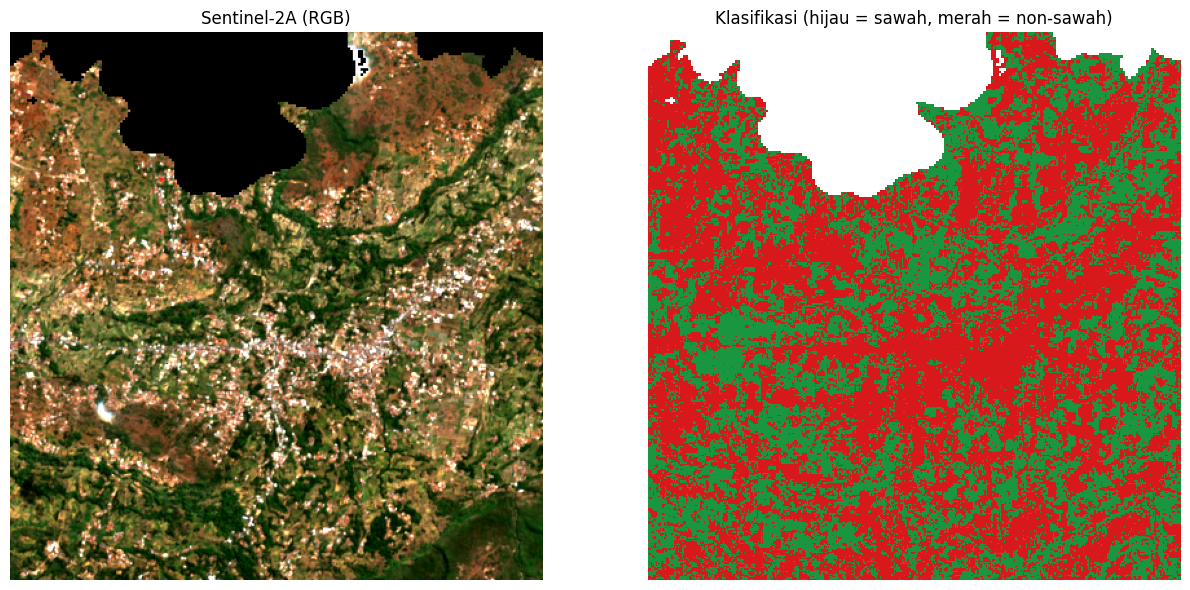


--- DISTRIBUSI KLASIFIKASI WILAYAH ---
 Sawah     : 42.19% (644.30 hektar)
 Non-Sawah : 57.81% (883.02 hektar)

Selesai. Output:
  GeoTIFF  : /content/klasifikasi_sawah_s2a.tif
  Pratinjau: /content/peta_klasifikasi.png
  Evaluasi : /content/hasil_evaluasi.txt


In [27]:
# --- HITUNG PERSENTASE DAN LUAS SAWAH VS NON-SAWAH ---
valid_pixels = classified[classified != 255]
total_valid = len(valid_pixels)

count_sawah = np.sum(valid_pixels == 1)
count_nonsawah = np.sum(valid_pixels == 0)

pct_sawah = (count_sawah / total_valid) * 100
pct_nonsawah = (count_nonsawah / total_valid) * 100

# Estimasi luas (Asumsi resolusi piksel Sentinel-2 adalah 10x10 meter = 100 m² per piksel)
luas_sawah_ha = (count_sawah * 100) / 10000
luas_nonsawah_ha = (count_nonsawah * 100) / 10000

# Catat ke dalam variabel LOG agar masuk ke file teks evaluasi
LOG.append(f"Total Piksel Valid: {total_valid}")
LOG.append(f"Sawah     : {pct_sawah:.2f}% ({count_sawah} piksel / {luas_sawah_ha:.2f} hektar)")
LOG.append(f"Non-Sawah : {pct_nonsawah:.2f}% ({count_nonsawah} piksel / {luas_nonsawah_ha:.2f} hektar)")
# -----------------------------------------------------

with rasterio.open(OUT_TIF, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="uint8", crs=crs, transform=transform,
                   nodata=255, compress="lzw") as dst:
    dst.write(classified, 1)
    dst.set_band_description(1, "kelas (1=sawah, 0=non-sawah)")
    dst.write_colormap(1, {0: (215, 25, 28, 255), 1: (26, 150, 65, 255),
                           255: (0, 0, 0, 0)})

rgb = np.dstack([B["B04"], B["B03"], B["B02"]])
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.nan_to_num(np.clip((rgb - lo) / (hi - lo + 1e-10), 0, 1))

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(rgb)
ax[0].set_title("Sentinel-2A (RGB)")
ax[1].imshow(np.ma.masked_equal(classified, 255),
             cmap=ListedColormap(["#d7191c", "#1a9641"]), vmin=0, vmax=1,
             interpolation="nearest")
ax[1].set_title("Klasifikasi (hijau = sawah, merah = non-sawah)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()

OUT_TXT.write_text("\n".join(LOG), encoding="utf-8")

print("\n--- DISTRIBUSI KLASIFIKASI WILAYAH ---")
print(f" Sawah     : {pct_sawah:.2f}% ({luas_sawah_ha:.2f} hektar)")
print(f" Non-Sawah : {pct_nonsawah:.2f}% ({luas_nonsawah_ha:.2f} hektar)")
print("\nSelesai. Output:")
print("  GeoTIFF  :", OUT_TIF)
print("  Pratinjau:", OUT_PNG)
print("  Evaluasi :", OUT_TXT)

**Penjelasan kode:** Kode ini menulis hasil klasifikasi ke `klasifikasi_sawah_s2a.tif` (kompresi LZW, nilai 255 sebagai *nodata*), membentuk citra RGB dari B04, B03, dan B02 dengan peregangan kontras persentil 2–98, menampilkan serta menyimpan peta `peta_klasifikasi.png`, dan menulis seluruh catatan `LOG` ke `hasil_evaluasi.txt`.